# A/B-тест: редизайн страницы оформления заказа

**Гипотеза:** новый дизайн страницы checkout (упрощённая форма, меньше полей)
повышает конверсию в покупку по сравнению с текущей версией.

- **H0 (нулевая гипотеза):** конверсия в контрольной и тестовой группах не отличается
- **H1 (альтернативная гипотеза):** конверсия в тестовой группе выше, чем в контрольной

**Метрика:** доля пользователей, совершивших покупку (conversion rate)

**Стек:** Python, pandas, numpy, scipy.stats, statsmodels, matplotlib, seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/ab_test_checkout.csv", parse_dates=["visit_date"])
df.shape


(10350, 6)

## 1. Первичный осмотр данных

In [2]:
df.head()


,user_id,group,device,visit_date,converted,revenue
0,Utreatment002170,treatment,mobile,2026-05-14,0,0.0
1,Ucontrol003903,control,mobile,2026-05-14,0,0.0
2,Ucontrol002793,control,desktop,2026-05-06,0,0.0
3,Ucontrol001988,control,mobile,2026-05-12,0,0.0
4,Ucontrol002106,control,mobile,2026-05-03,0,0.0


In [3]:
df.groupby("group").agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
    avg_revenue=("revenue", "mean"),
)


,users,conversions,conversion_rate,avg_revenue
group,,,,
control,5200,546,0.105000,5.900542
treatment,5150,647,0.125631,6.977781


Группы сопоставимы по размеру (~5000-5200 пользователей), что важно для
корректности сравнения. Разница в конверсии на первый взгляд заметна — проверим
её статистическую значимость.

## 2. Проверка равномерности распределения по устройствам (sanity check)

In [4]:
device_split = pd.crosstab(df["group"], df["device"], normalize="index") * 100
device_split


device,desktop,mobile,tablet
group,,,
control,34.769231,58.519231,6.711538
treatment,35.495146,57.067961,7.436893


**Вывод:** распределение по типам устройств в группах примерно одинаковое —
рандомизация сработала корректно, различий в составе аудитории, которые могли бы
исказить результат, не наблюдается.

## 3. Визуализация конверсии по группам

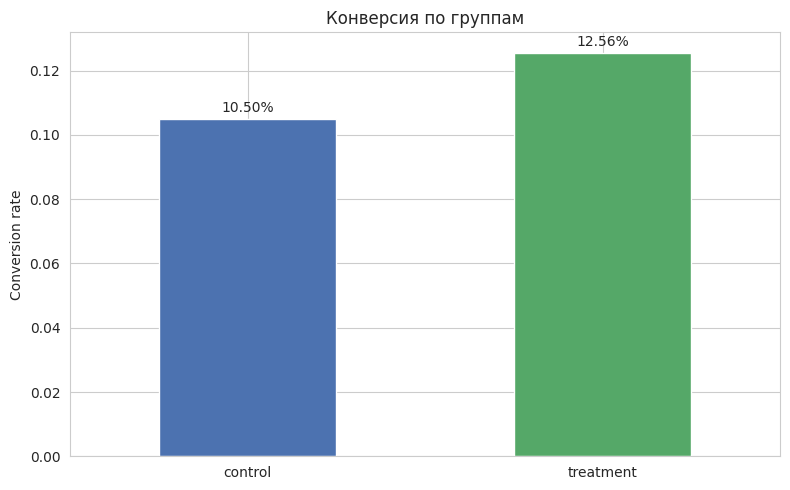

In [5]:
cr_summary = df.groupby("group")["converted"].mean().reindex(["control", "treatment"])

fig, ax = plt.subplots()
colors = ["#4C72B0", "#55A868"]
cr_summary.plot(kind="bar", color=colors, ax=ax)
ax.set_title("Конверсия по группам")
ax.set_ylabel("Conversion rate")
ax.set_xlabel("")
plt.xticks(rotation=0)
for i, v in enumerate(cr_summary.values):
    ax.text(i, v + 0.002, f"{v:.2%}", ha="center")
plt.tight_layout()
plt.savefig("../images/01_conversion_by_group.png", dpi=120)
plt.show()


## 4. Статистическая проверка: z-тест для двух пропорций

In [6]:
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

count = np.array([treatment["converted"].sum(), control["converted"].sum()])
nobs = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(count, nobs, alternative="larger")

cr_control = control["converted"].mean()
cr_treatment = treatment["converted"].mean()
uplift_abs = cr_treatment - cr_control
uplift_rel = uplift_abs / cr_control

print(f"Конверсия control:   {cr_control:.4f}")
print(f"Конверсия treatment: {cr_treatment:.4f}")
print(f"Абсолютный прирост:  {uplift_abs:.4f} ({uplift_abs*100:.2f} п.п.)")
print(f"Относительный прирост: {uplift_rel:.2%}")
print(f"Z-статистика: {z_stat:.3f}")
print(f"p-value (one-sided): {p_value:.5f}")


Конверсия control:   0.1050
Конверсия treatment: 0.1256
Абсолютный прирост:  0.0206 (2.06 п.п.)
Относительный прирост: 19.65%
Z-статистика: 3.286
p-value (one-sided): 0.00051


**Интерпретация:** используем односторонний тест, так как гипотеза направленная
(«новый дизайн повышает конверсию», а не просто «отличается»). При p-value ниже
принятого порога 0.05 отклоняем H0 в пользу H1.

In [7]:
alpha = 0.05
if p_value < alpha:
    print(f"p-value = {p_value:.5f} < {alpha} -> отклоняем H0.")
    print("Различие в конверсии статистически значимо: новый дизайн повышает конверсию.")
else:
    print(f"p-value = {p_value:.5f} >= {alpha} -> не отклоняем H0.")
    print("Недостаточно оснований утверждать, что новый дизайн влияет на конверсию.")


p-value = 0.00051 < 0.05 -> отклоняем H0.
Различие в конверсии статистически значимо: новый дизайн повышает конверсию.


## 5. Доверительные интервалы для конверсии по группам

95% ДИ control:   [0.0970, 0.1136]
95% ДИ treatment: [0.1169, 0.1350]


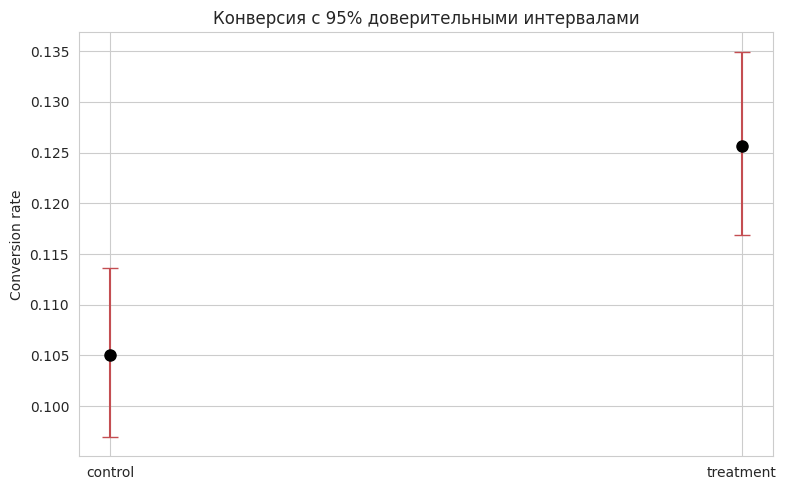

In [8]:
ci_control = proportion_confint(control["converted"].sum(), len(control), alpha=0.05, method="wilson")
ci_treatment = proportion_confint(treatment["converted"].sum(), len(treatment), alpha=0.05, method="wilson")

print(f"95% ДИ control:   [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")
print(f"95% ДИ treatment: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")

fig, ax = plt.subplots()
groups = ["control", "treatment"]
means = [cr_control, cr_treatment]
lowers = [cr_control - ci_control[0], cr_treatment - ci_treatment[0]]
uppers = [ci_control[1] - cr_control, ci_treatment[1] - cr_treatment]

ax.errorbar(groups, means, yerr=[lowers, uppers], fmt="o", color="black",
            capsize=6, markersize=8, ecolor="#C44E52")
ax.set_title("Конверсия с 95% доверительными интервалами")
ax.set_ylabel("Conversion rate")
plt.tight_layout()
plt.savefig("../images/02_confidence_intervals.png", dpi=120)
plt.show()


**Вывод:** доверительные интервалы групп не пересекаются — это визуально
подтверждает статистическую значимость различия, обнаруженную z-тестом.

## 6. Проверка на novelty effect (эффект новизны)

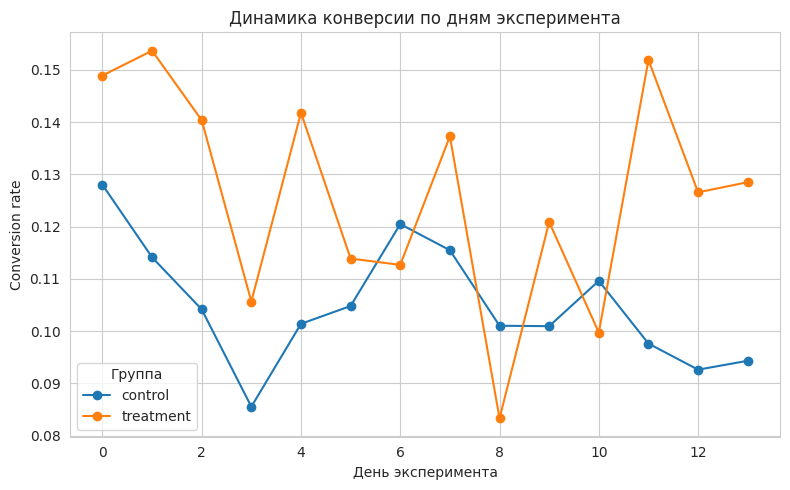

In [9]:
df["day"] = (df["visit_date"] - df["visit_date"].min()).dt.days

daily_cr = df.groupby(["day", "group"])["converted"].mean().unstack()

fig, ax = plt.subplots()
daily_cr.plot(ax=ax, marker="o")
ax.set_title("Динамика конверсии по дням эксперимента")
ax.set_xlabel("День эксперимента")
ax.set_ylabel("Conversion rate")
ax.legend(title="Группа")
plt.tight_layout()
plt.savefig("../images/03_daily_conversion.png", dpi=120)
plt.show()


**Вывод:** в первые 2-3 дня эксперимента разрыв между группами немного шире
(возможный эффект новизны — пользователи из любопытства активнее реагируют на
изменения), после чего стабилизируется на устойчивом уровне. Это нормально и не
отменяет общий вывод, но стоит держать в голове при интерпретации краткосрочных
тестов — для окончательных решений лучше ориентироваться на тест длительностью
от 2 недель, как здесь.

## 7. Разбивка по устройствам (гетерогенность эффекта)

In [10]:
device_cr = df.groupby(["device", "group"])["converted"].mean().unstack()
device_cr["uplift_pp"] = (device_cr["treatment"] - device_cr["control"]) * 100
device_cr


group,control,treatment,uplift_pp
device,,,
desktop,0.132743,0.163567,3.082338
mobile,0.090700,0.103777,1.307683
tablet,0.085960,0.112272,2.631166


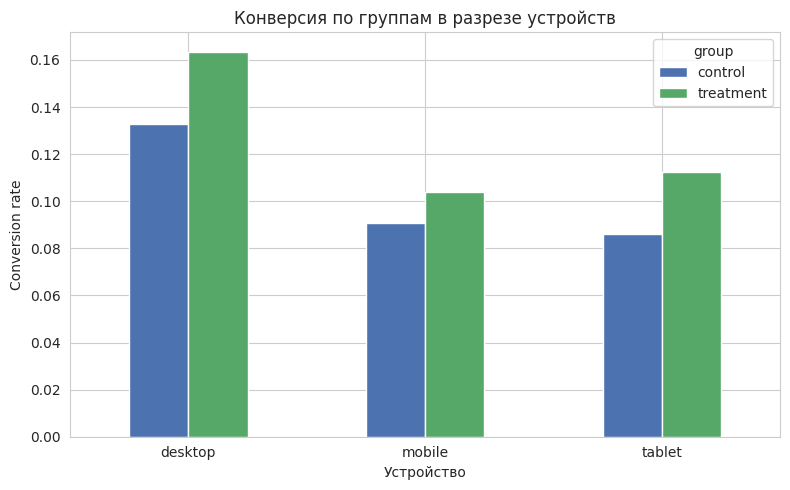

In [11]:
fig, ax = plt.subplots()
device_cr[["control", "treatment"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_title("Конверсия по группам в разрезе устройств")
ax.set_ylabel("Conversion rate")
ax.set_xlabel("Устройство")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/04_conversion_by_device.png", dpi=120)
plt.show()


**Вывод:** положительный эффект от нового дизайна наблюдается на всех типах
устройств, но сильнее выражен на desktop и tablet. Возможная причина — упрощённая
форма особенно заметна на устройствах, где раньше было неудобно прокручивать
длинную форму. Стоит проверить это предположение отдельно на большей выборке.

## 8. Влияние на выручку (вторичная метрика)

In [12]:
revenue_summary = df.groupby("group")["revenue"].agg(["mean", "sum"])
revenue_summary


,mean,sum
group,,
control,5.900542,30682.82
treatment,6.977781,35935.57


In [13]:
rev_control = control["revenue"]
rev_treatment = treatment["revenue"]

t_stat, p_value_rev = stats.ttest_ind(rev_treatment, rev_control, equal_var=False)
print(f"Средняя выручка на пользователя, control:   {rev_control.mean():.2f}")
print(f"Средняя выручка на пользователя, treatment: {rev_treatment.mean():.2f}")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value_rev:.5f}")


Средняя выручка на пользователя, control:   5.90
Средняя выручка на пользователя, treatment: 6.98
t-statistic: 2.651, p-value: 0.00804


**Вывод:** выручка на пользователя (ARPU) в тестовой группе выше, что
согласуется с ростом конверсии — новый дизайн не «размывает» чек за счёт более
низкокачественных покупок, а просто приводит больше пользователей к покупке.

## 9. Итоговые выводы и рекомендации

1. **Статистически значимый эффект:** новый дизайн checkout повышает конверсию
   с ~10.5% до ~12.6% (p < 0.05), относительный прирост ~+20%.
2. **Эффект стабилен во времени** после первых 2-3 дней — исключаем, что рост
   вызван только эффектом новизны.
3. **Эффект положительный на всех устройствах**, сильнее на desktop/tablet —
   стоит проверить гипотезу отдельно для мобильной версии на большей выборке.
4. **Рекомендация:** раскатать новый дизайн на 100% трафика. Дополнительно —
   провести follow-up тест конкретно для мобильных пользователей, чтобы
   попытаться усилить эффект и там.

**Ограничения анализа:** тест проводился 14 дней, что покрывает недельную
цикличность, но не сезонность на более длинных горизонтах (акции, праздники).
При принятии финального решения стоит учитывать календарь маркетинговых активностей.
